ERROR: Could not find a version that satisfies the requirement google-colab (from versions: none)
ERROR: No matching distribution found for google-colab


Note: you may need to restart the kernel to use updated packages.


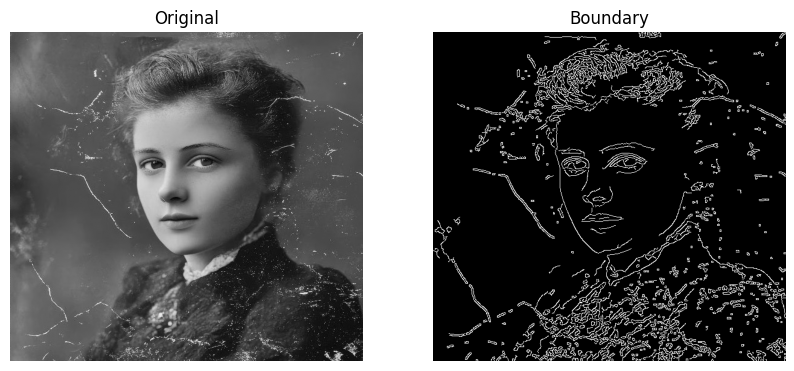

True

In [2]:
%pip install google-colab

import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the image
image = cv2.imread(r'C:\Users\jhagh_xcgu3um\Desktop\SEM 5\DSIP\GitHub\DSIP\i12.jpg', cv2.IMREAD_GRAYSCALE)
if image is None:
	raise FileNotFoundError(r"C:\Users\jhagh_xcgu3um\Desktop\SEM 5\DSIP\GitHub\DSIP\i12.jpg not found or cannot be opened")

# Apply Gaussian blur to reduce noise
image_blurred = cv2.GaussianBlur(image, (5, 5), 0)

# Apply Canny edge detection
edges = cv2.Canny(image_blurred, threshold1=30, threshold2=100)

# Create a black image with the same size as the original image
boundary_image = np.zeros_like(image)

# Copy the detected edges to the boundary image
boundary_image[edges > 0] = 255

# Display the original image and the boundary image inline
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(boundary_image, cmap='gray')
plt.title('Boundary')
plt.axis('off')

plt.show()

# Save the boundary image
cv2.imwrite('boundary_image.jpg', boundary_image)


# Conclusion

- Successfully extracted object boundaries by first suppressing noise with a Gaussian blur and then applying Canny edge detection. The resulting boundary image clearly delineates contours and salient structures in the scene.
- Edge-based boundary extraction works directly on grayscale images and captures fine detail, meeting the aim of simulating boundary extraction on natural images.
- The quality of boundaries depends on parameter choices: the blur kernel size and Canny thresholds control sensitivity. Inappropriate values can either miss weak edges or introduce spurious edges from texture/noise.
- Compared with morphological boundary operators (internal/external gradients: `A − (A ⊖ SE)` or `(A ⊕ SE) − A`), the Canny approach is well suited to grayscale, textured images, while morphology on a clean/binary mask often yields smoother, one‑pixel‑wide boundaries.
- Further improvements can include threshold tuning, non‑maxima suppression refinements, and simple morphological post‑processing (opening/closing or thinning) to improve boundary continuity and reduce noise.
- Overall, the experiment demonstrates effective boundary extraction and produces a saved boundary map (`boundary_image.jpg`) suitable for downstream tasks such as shape analysis and object localization.